# Exploratory Data Analysis

#### 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

#### 2. Load cleaned data

In [2]:
df = pd.read_csv("../data/processed/cardekho_cleaned.csv")

df.head()

print(df.shape)

(15411, 13)


#### 3. Numerical distributions

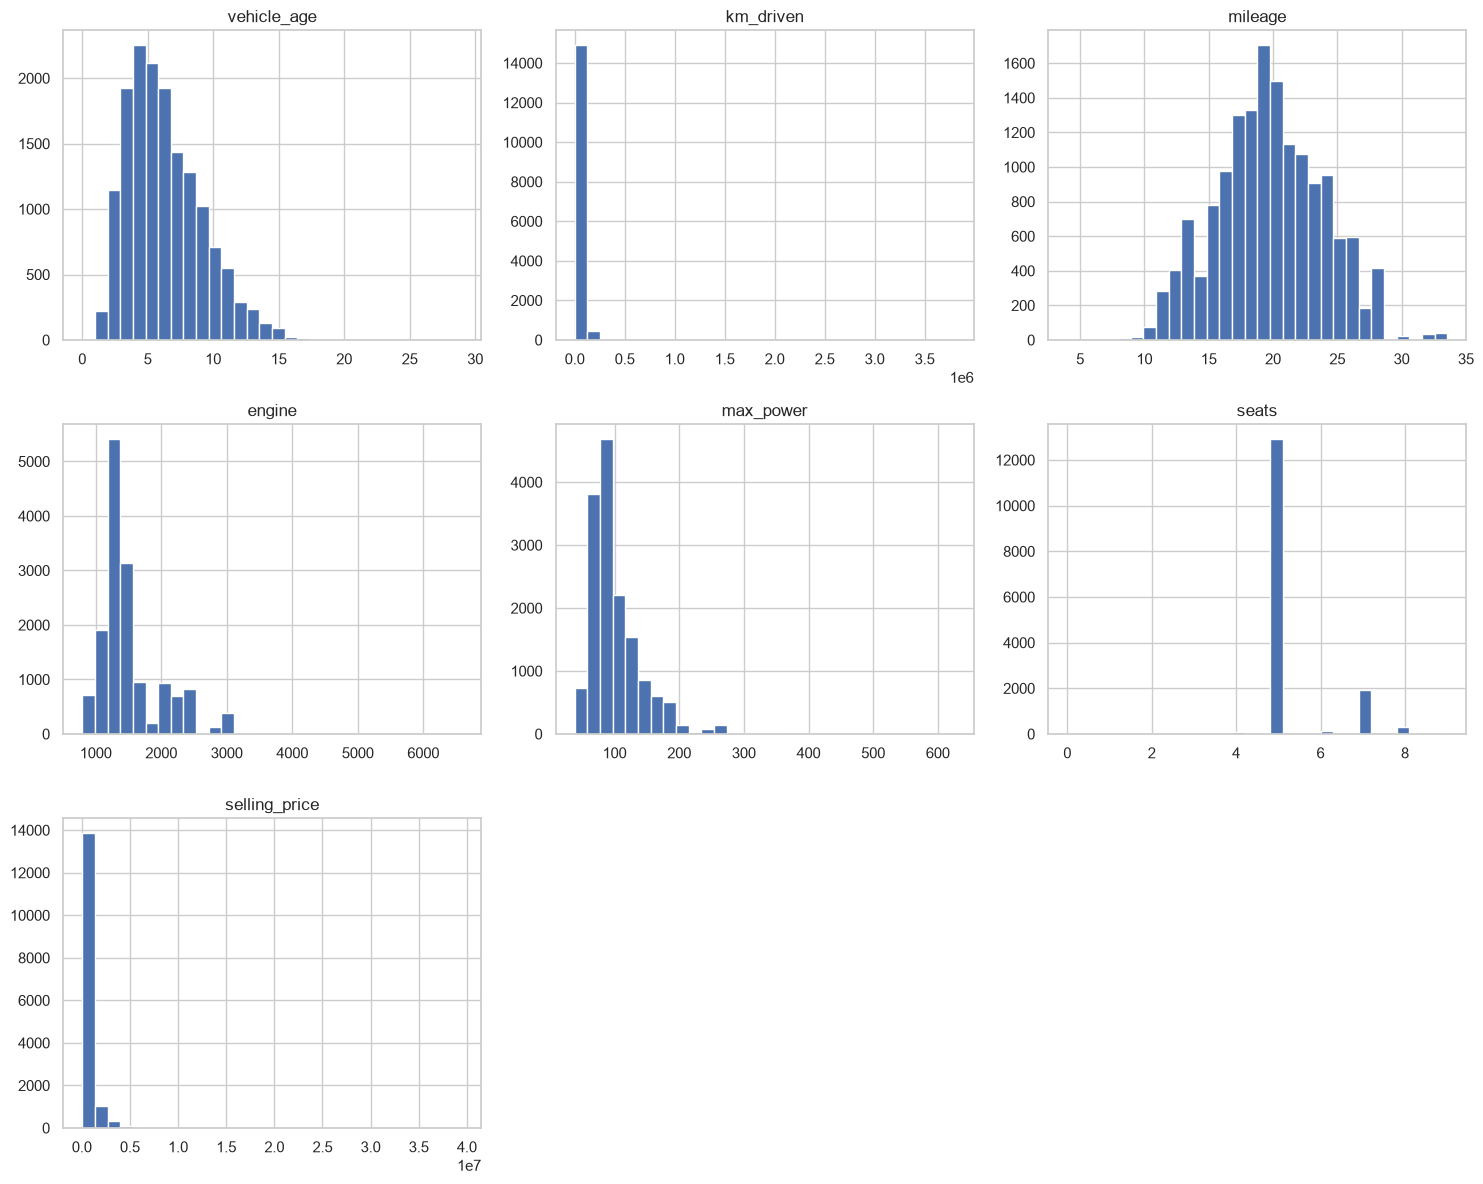

In [3]:
numerical_columns = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "selling_price"
]

df[numerical_columns].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

#### 4. Selling price distribution

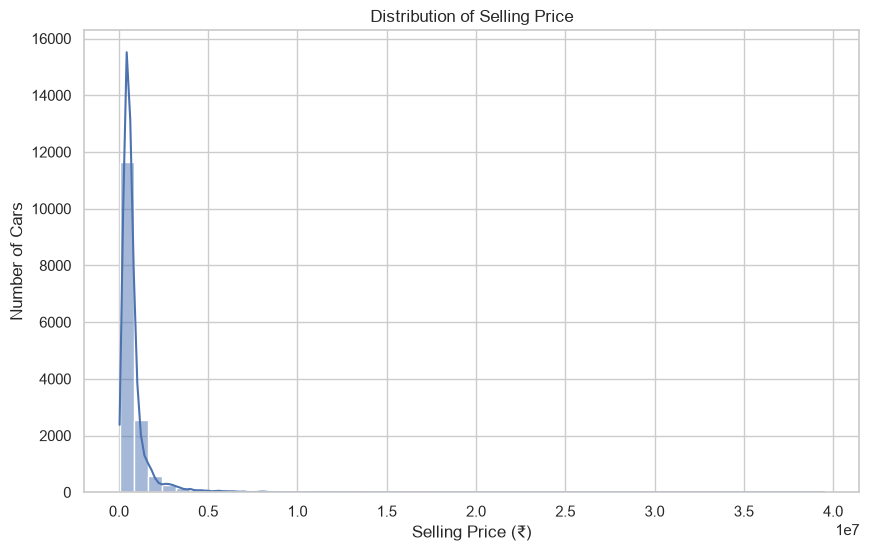

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="selling_price",
    bins=50,
    kde=True
)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (₹)")
plt.ylabel("Number of Cars")

plt.show()

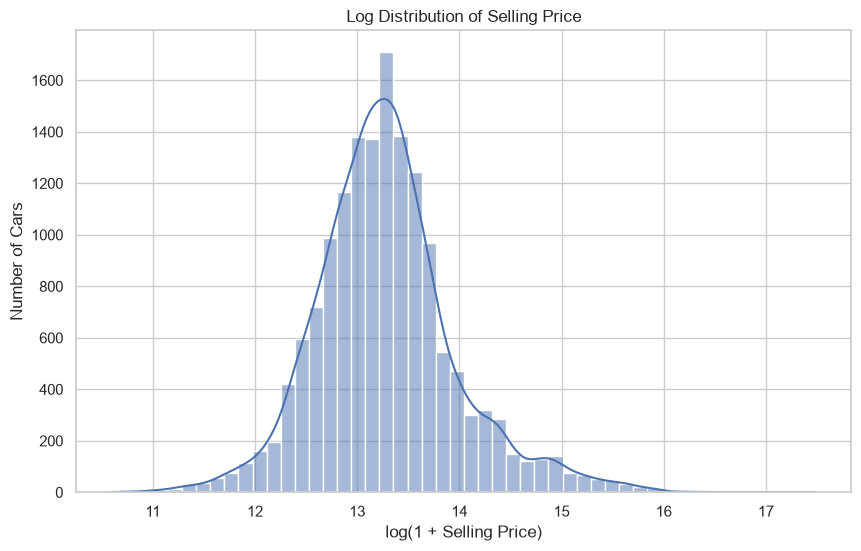

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(df["selling_price"]),
    bins=50,
    kde=True
)

plt.title("Log Distribution of Selling Price")
plt.xlabel("log(1 + Selling Price)")
plt.ylabel("Number of Cars")

plt.show()

#### 5. Vehicle age vs price

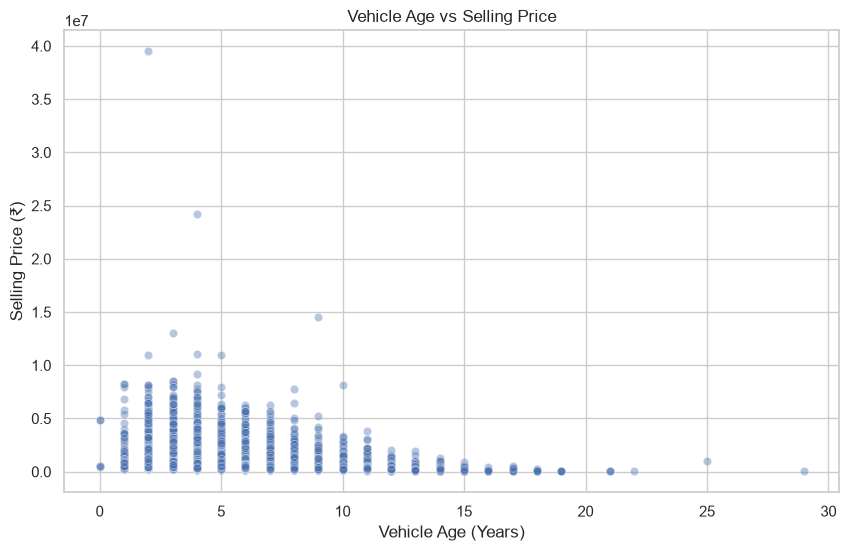

In [6]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="vehicle_age",
    y="selling_price",
    alpha=0.4
)

plt.title("Vehicle Age vs Selling Price")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Selling Price (₹)")

plt.show()

In [7]:
age_price = (
    df.groupby("vehicle_age")["selling_price"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

age_price

,vehicle_age,count,mean,median
0,0,5,2.230000e+06,550000.0
1,1,221,1.096977e+06,750000.0
2,2,1145,1.143023e+06,820000.0
3,3,1926,9.770950e+05,745000.0
4,4,2252,9.509427e+05,695500.0
5,5,2117,8.188928e+05,600000.0
6,6,1924,7.285146e+05,550000.0
7,7,1438,6.990758e+05,500000.0
8,8,1282,6.259454e+05,450000.0
9,9,1027,5.924664e+05,400000.0


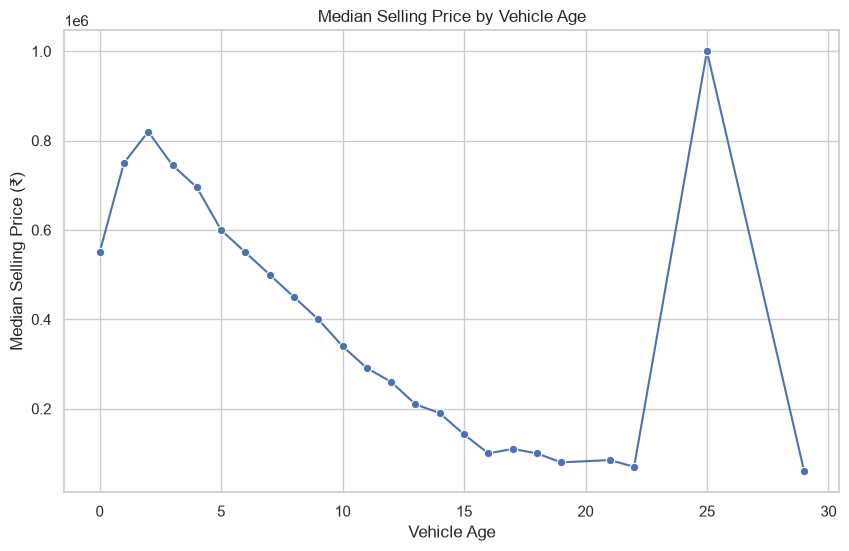

In [8]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=age_price,
    x="vehicle_age",
    y="median",
    marker="o"
)

plt.title("Median Selling Price by Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Median Selling Price (₹)")

plt.show()

#### 6. KM driven vs price

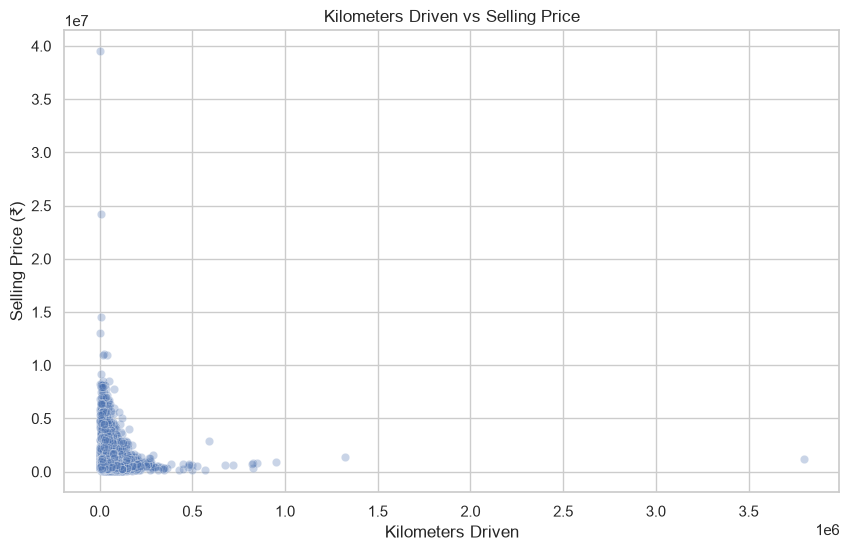

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price",
    alpha=0.3
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (₹)")

plt.show()

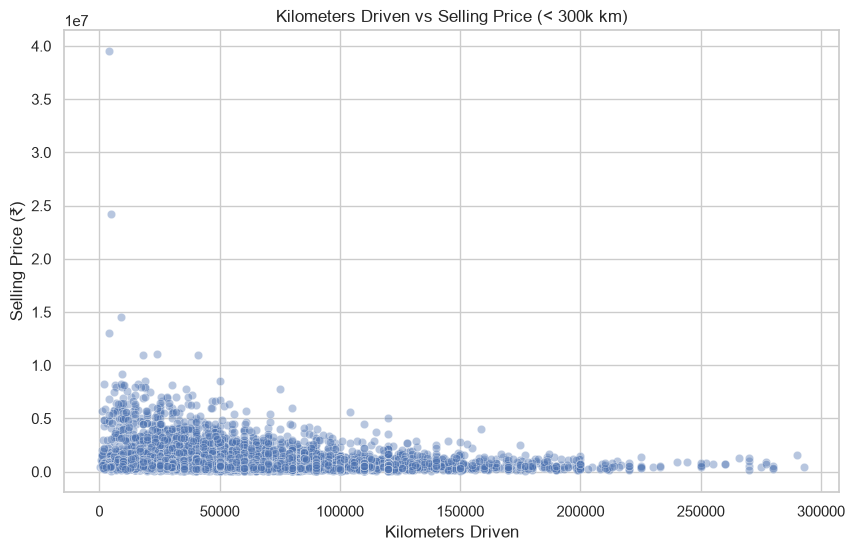

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df[df["km_driven"] < 300000],
    x="km_driven",
    y="selling_price",
    alpha=0.4
)

plt.title("Kilometers Driven vs Selling Price (< 300k km)")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (₹)")

plt.show()

#### 7. Mileage vs price

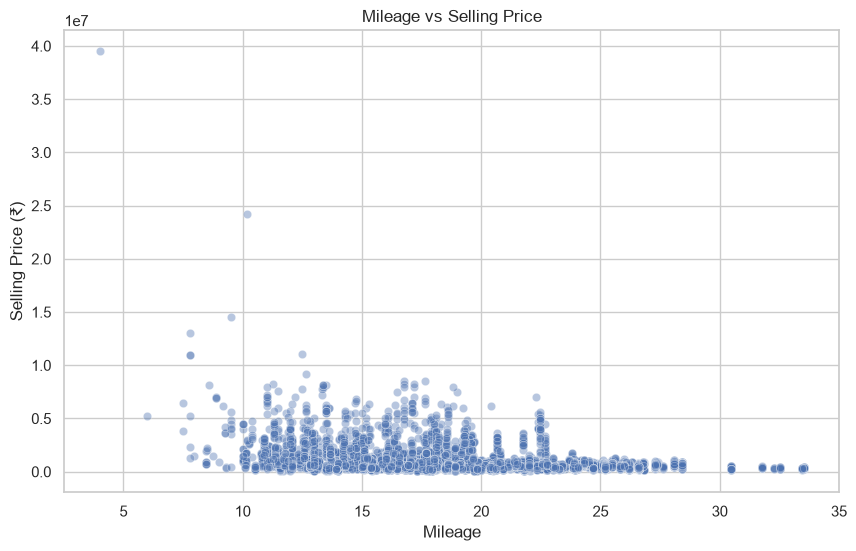

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="mileage",
    y="selling_price",
    alpha=0.4
)

plt.title("Mileage vs Selling Price")
plt.xlabel("Mileage")
plt.ylabel("Selling Price (₹)")

plt.show()

#### 8. Engine vs price

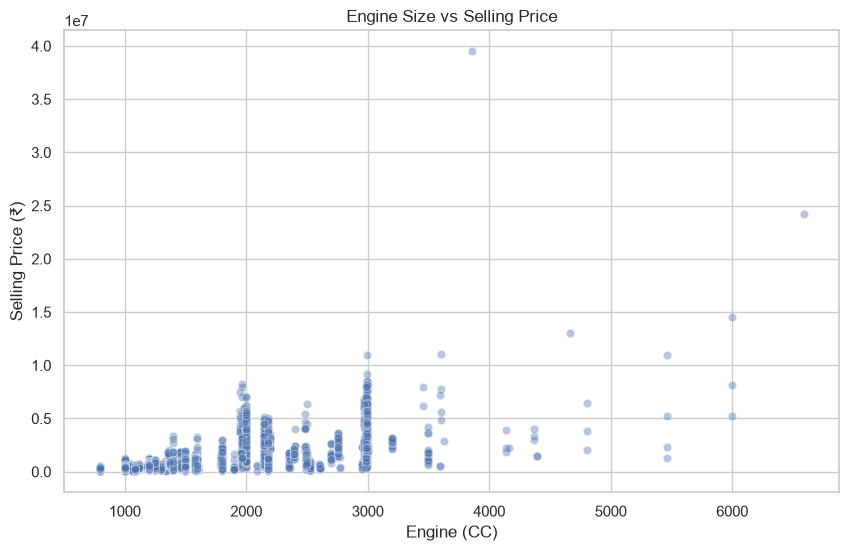

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="engine",
    y="selling_price",
    alpha=0.4
)

plt.title("Engine Size vs Selling Price")
plt.xlabel("Engine (CC)")
plt.ylabel("Selling Price (₹)")

plt.show()

#### 9. Power vs price

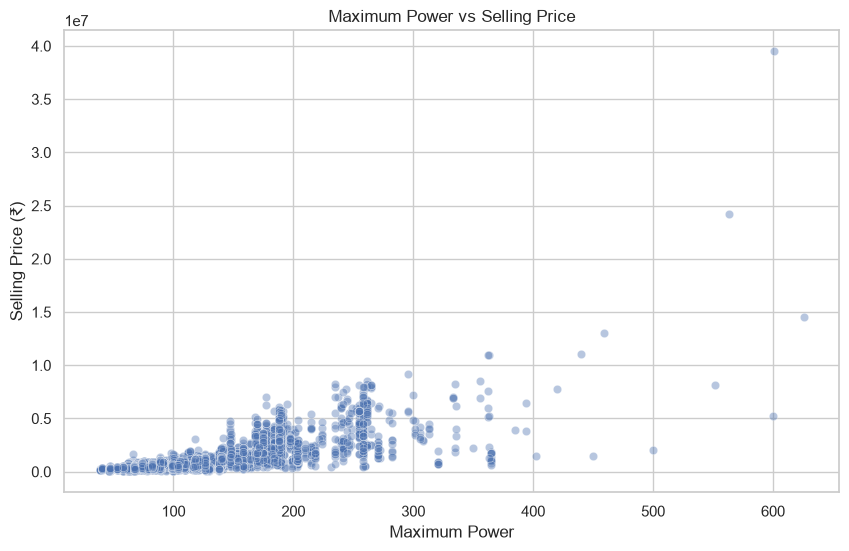

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="max_power",
    y="selling_price",
    alpha=0.4
)

plt.title("Maximum Power vs Selling Price")
plt.xlabel("Maximum Power")
plt.ylabel("Selling Price (₹)")

plt.show()

#### 10. Brand analysis

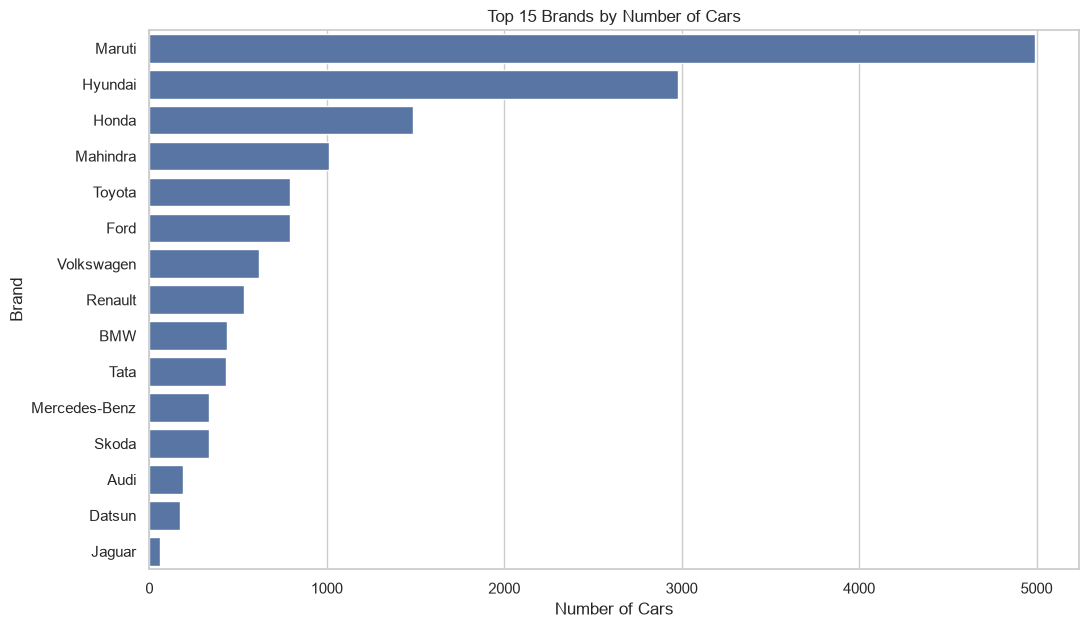

In [14]:
brand_counts = df["brand"].value_counts()

plt.figure(figsize=(12, 7))

sns.barplot(
    x=brand_counts.head(15).values,
    y=brand_counts.head(15).index
)

plt.title("Top 15 Brands by Number of Cars")
plt.xlabel("Number of Cars")
plt.ylabel("Brand")

plt.show()

#### 11. Brand vs selling price

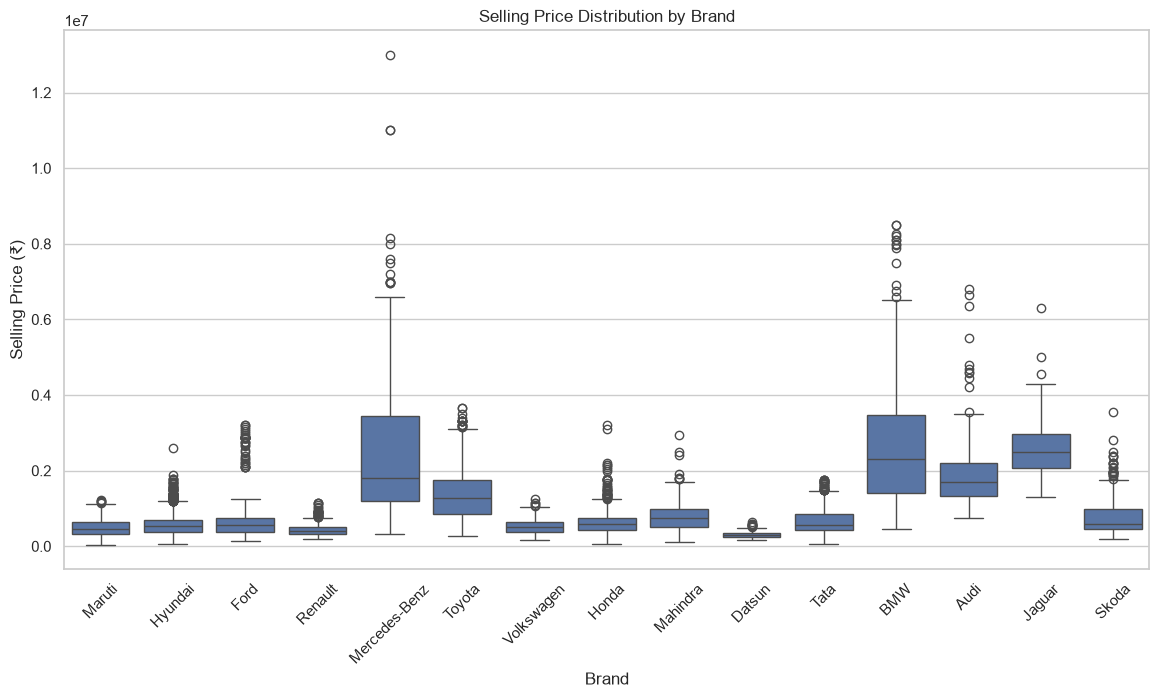

In [15]:
top_brands = df["brand"].value_counts().head(15).index

brand_data = df[df["brand"].isin(top_brands)]

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=brand_data,
    x="brand",
    y="selling_price"
)

plt.xticks(rotation=45)

plt.title("Selling Price Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("Selling Price (₹)")

plt.show()

#### 12. Fuel type

In [16]:
fuel_stats = (
    df.groupby("fuel_type")["selling_price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

fuel_stats

,count,mean,median
fuel_type,,,
Electric,4,1.853500e+06,1857500.0
Diesel,7419,1.000469e+06,700000.0
Petrol,7643,5.728619e+05,460000.0
CNG,301,4.176877e+05,370000.0
LPG,44,2.062727e+05,182500.0


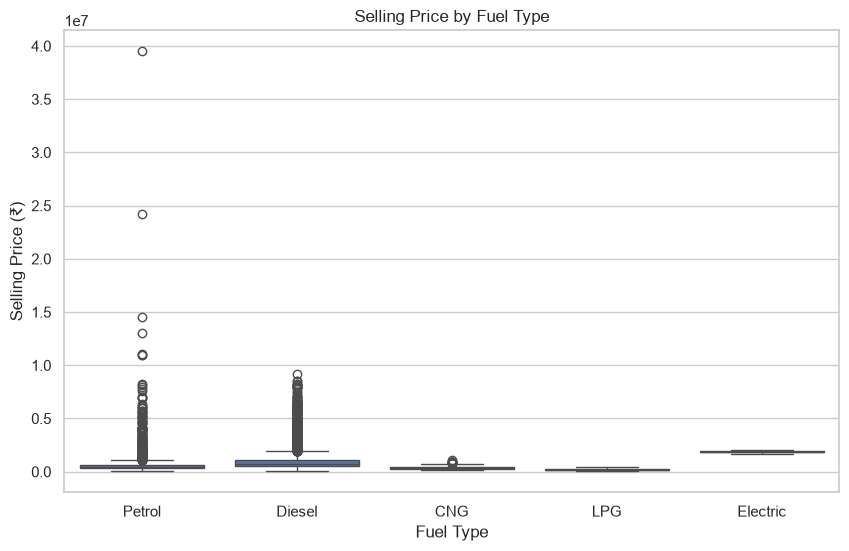

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="fuel_type",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (₹)")

plt.show()

#### 13. Transmission

In [18]:
transmission_stats = (
    df.groupby("transmission_type")["selling_price"]
    .agg(["count", "mean", "median"])
)

transmission_stats

,count,mean,median
transmission_type,,,
Automatic,3186,1.579557e+06,1057000.0
Manual,12225,5.652852e+05,500000.0


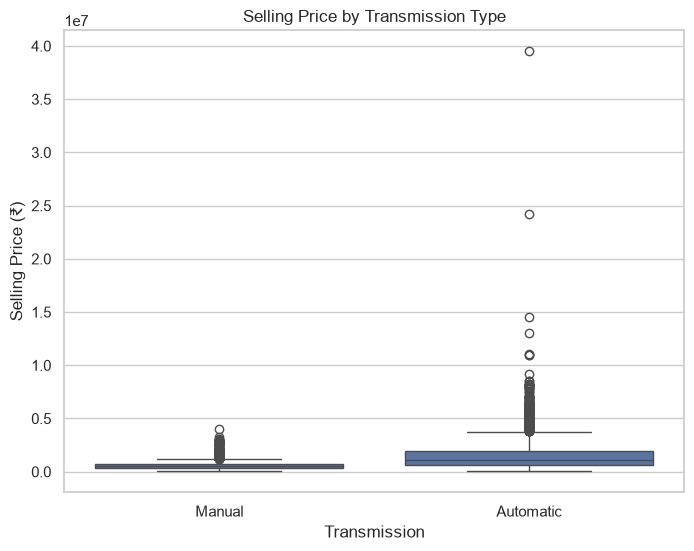

In [19]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="transmission_type",
    y="selling_price"
)

plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price (₹)")

plt.show()

#### 14. Seller type

In [20]:
seller_stats = (
    df.groupby("seller_type")["selling_price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

seller_stats

,count,mean,median
seller_type,,,
Dealer,9539,872505.503722,591000.0
Trustmark Dealer,173,571959.537572,540000.0
Individual,5699,617880.483418,507000.0


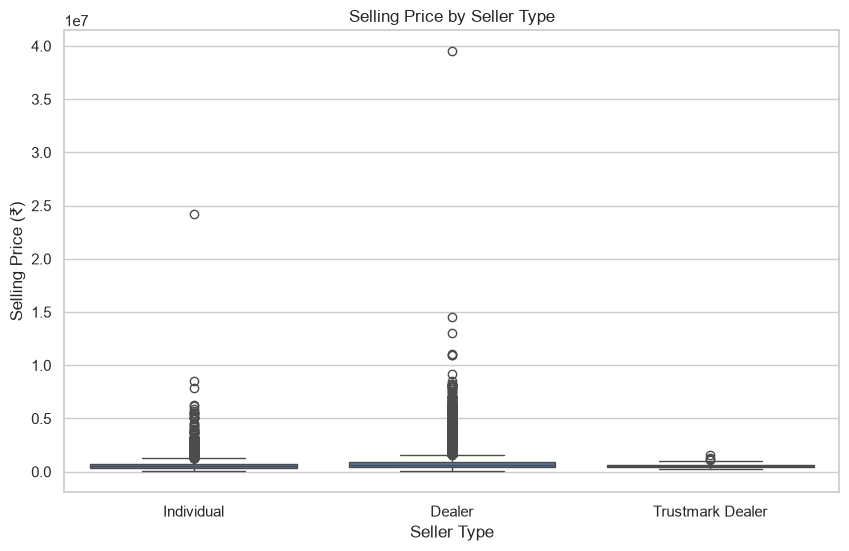

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="seller_type",
    y="selling_price"
)

plt.title("Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price (₹)")

plt.show()

#### 15. Seats

In [22]:
print(df[df["seats"] == 0])

           car_name   brand  model  vehicle_age  km_driven seller_type  \
3217     Honda City   Honda   City           18      40000  Individual   
12619  Nissan Kicks  Nissan  Kicks            2      10000  Individual   

      fuel_type transmission_type  mileage  engine  max_power  seats  \
3217     Petrol            Manual    13.00    1493     100.00      0   
12619    Diesel            Manual    19.39    1461     108.49      0   

       selling_price  
3217          115000  
12619        1154000  


In [23]:
print("Cars with 0 seats:", (df["seats"] == 0).sum())

Cars with 0 seats: 2


In [24]:
print(
    df.groupby("seats")["selling_price"]
    .agg(["count", "mean", "median"])
)

       count          mean     median
seats                                
0          2  6.345000e+05   634500.0
2          7  4.124286e+06  3425000.0
4         77  3.974597e+06  3200000.0
5      12910  6.942537e+05   525000.0
6        127  6.467874e+05   551000.0
7       1922  1.164031e+06   875000.0
8        311  9.293601e+05   800000.0
9         55  6.480000e+05   595000.0


#### 16. Investigate extreme KM values

In [25]:
df.nlargest(20, "km_driven")[
    [
        "car_name",
        "brand",
        "model",
        "vehicle_age",
        "km_driven",
        "selling_price"
    ]
]

,car_name,brand,model,vehicle_age,km_driven,selling_price
15409,Mahindra XUV500,Mahindra,XUV500,5,3800000,1225000
11903,Mercedes-Benz E-Class,Mercedes-Benz,E-Class,9,1325000,1350000
8772,Toyota Innova,Toyota,Innova,6,950000,950000
4532,Renault Duster,Renault,Duster,4,850000,850000
6712,Volkswagen Vento,Volkswagen,Vento,9,830000,380000
10838,Hyundai Creta,Hyundai,Creta,6,825000,825000
11615,Volkswagen Polo,Volkswagen,Polo,5,820000,695000
7323,Ford Ecosport,Ford,Ecosport,6,720000,675000
9170,Skoda Rapid,Skoda,Rapid,5,675000,675000
7534,Toyota Fortuner,Toyota,Fortuner,2,590000,2850000


#### 17. Outlier detection using IQR

In [26]:
def outlier_summary(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]
    
    print(f"Column: {column}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print(f"Number of Outliers: {len(outliers)}")
    print(f"Percentage: {(len(outliers)/len(data))*100:.2f}%")

In [27]:
for column in [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "selling_price"
]:
    outlier_summary(df, column)
    print("-" * 50)

Column: vehicle_age
Q1: 4.0
Q3: 8.0
IQR: 4.0
Lower Bound: -2.0
Upper Bound: 14.0
Number of Outliers: 154
Percentage: 1.00%
--------------------------------------------------
Column: km_driven
Q1: 30000.0
Q3: 70000.0
IQR: 40000.0
Lower Bound: -30000.0
Upper Bound: 130000.0
Number of Outliers: 466
Percentage: 3.02%
--------------------------------------------------
Column: mileage
Q1: 17.0
Q3: 22.7
IQR: 5.699999999999999
Lower Bound: 8.450000000000001
Upper Bound: 31.25
Number of Outliers: 88
Percentage: 0.57%
--------------------------------------------------
Column: engine
Q1: 1197.0
Q3: 1582.0
IQR: 385.0
Lower Bound: 619.5
Upper Bound: 2159.5
Number of Outliers: 2130
Percentage: 13.82%
--------------------------------------------------
Column: max_power
Q1: 74.0
Q3: 117.3
IQR: 43.3
Lower Bound: 9.050000000000011
Upper Bound: 182.25
Number of Outliers: 867
Percentage: 5.63%
--------------------------------------------------
Column: selling_price
Q1: 385000.0
Q3: 825000.0
IQR: 440000.0


#### 18. Model-related correlation analysis

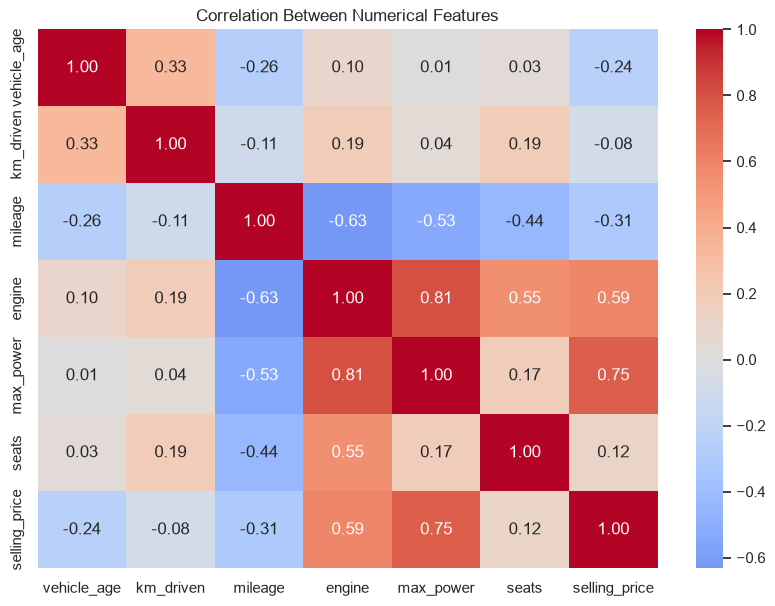

In [28]:
corr = df[numerical_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Numerical Features")

plt.show()

In [29]:
brand_age_price = (
    df.groupby(["brand", "vehicle_age"])["selling_price"]
    .median()
    .reset_index()
)

brand_age_price.head(20)

,brand,vehicle_age,selling_price
0,Audi,1,5700000.0
1,Audi,2,5422500.0
2,Audi,3,3490000.0
3,Audi,4,2950000.0
4,Audi,5,2675000.0
5,Audi,6,2412500.0
6,Audi,7,1750500.0
7,Audi,8,1495000.0
8,Audi,9,1345000.0
9,Audi,10,1100000.0
